In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import requests


In [157]:
from pysus.online_data import SINAN
metadata = SINAN.metadata_df('LEIV')
metadata.to_excel("data/metadata_LEIV.xlsx", index=False, freeze_panes=(1,0))


from pysus.ftp.databases.sinan import SINAN
sinan = SINAN().load()
arquivo = sinan.get_files('LEIV')
print (arquivo)

In [158]:
dados = sinan.download(sinan.get_files('LEIV', 2025))
df = dados.to_dataframe()

334996it [00:00, 51805731.98it/s]    


In [159]:
print ("== HEAD ==")
print (df.head())
print ("== SHAPE ==")
print (df.shape)
print ("== COLUMNS ==")
print (df.columns)
print ("== INFO ==")
df.info()

== HEAD ==
  TP_NOT ID_AGRAVO  DT_NOTIFIC SEM_NOT NU_ANO SG_UF_NOT ID_MUNICIP ID_REGIONA  \
0      2      B550  2025-01-01  202501   2025        50     500830   6255       
1      2      B550  2025-01-01  202501   2025        17     170210              
2      2      B550  2025-01-01  202501   2025        15     150140   1484       
3      2      B550  2025-01-01  202501   2025        50     500830   6255       
4      2      B550  2025-01-01  202501   2025        50     500270   1975       

  ID_UNIDADE  DT_SIN_PRI  ... DS_TRANS_1 DT_DESLC2 DS_MUN_2 CO_UF_2 CO_PAIS_2  \
0    2945622  2025-01-01  ...                                                   
1    3663051  2025-01-01  ...                                                   
2    2752700  2024-12-02  ...                                                   
3    2945622  2025-01-01  ...                                                   
4    0009733  2025-01-01  ...                                                   

  DS_TRANS_2 DT

In [160]:
colunas_categorias = df.nunique().sort_values()[df.nunique().sort_values() < 10].index
print (colunas_categorias)
colunas_nao_categorias = df.nunique().sort_values()[df.nunique().sort_values() >= 10].index
print (colunas_nao_categorias)

Index(['TP_NOT', 'ID_AGRAVO', 'MIGRADO_W', 'NU_ANO', 'FLXRECEBI', 'CS_FLXRET',
       'CO_PAIS_1', 'CS_SEXO', 'CO_PAIS_3', 'CO_PAIS_2', 'CRITERIO',
       'NDUPLIC_N', 'DIAG_PAR_N', 'TOSSE', 'PALIDEZ', 'BACO', 'INFECCIOSO',
       'FEN_HEMORR', 'ICTERICIA', 'HIV', 'EMAGRA', 'IFI', 'OUTRO', 'DOSE',
       'CLASSI_FIN', 'TPAUTOCTO', 'DOENCA_TRA', 'OUTROS', 'EDEMA', 'FIGADO',
       'FEBRE', 'FRAQUEZA', 'COPAISINF', 'FALENCIA', 'ENTRADA', 'ID_PAIS',
       'EVOLUCAO', 'CS_RACA', 'DROGA', 'CS_GESTANT', 'DS_TRANS_2',
       'DT_DESLC3'],
      dtype='object')
Index(['CO_UF_3', 'CS_ESCOL_N', 'CO_UF_2', 'DS_MUN_3', 'DS_TRANS_1',
       'DT_DESLC2', 'CO_UF_1', 'COUFINF', 'SG_UF_NOT', 'SG_UF', 'AMPOLAS',
       'SEM_NOT', 'DT_DESLC1', 'DS_MUN_2', 'DS_MUN_1', 'PESO', 'ANO_NASC',
       'NU_IDADE_N', 'SEM_PRI', 'DT_OBITO', 'ID_REGIONA', 'DT_DIGITA',
       'TRATAMENTO', 'DT_ENCERRA', 'ID_RG_RESI', 'DT_INVEST', 'DT_NOTIFIC',
       'ID_OCUPA_N', 'COMUNINF', 'DT_SIN_PRI', 'ID_MUNICIP', 'OUTROS_ESP'

In [161]:
for coluna in colunas_categorias:
    print(f"\n {'='*50}")
    print(f"Coluna: {coluna}")
    print(df[coluna].value_counts(dropna=False))


Coluna: TP_NOT
TP_NOT
2    6026
Name: count, dtype: Int64

Coluna: ID_AGRAVO
ID_AGRAVO
B550    6026
Name: count, dtype: Int64

Coluna: MIGRADO_W
MIGRADO_W
    6026
Name: count, dtype: Int64

Coluna: NU_ANO
NU_ANO
2025    6026
Name: count, dtype: Int64

Coluna: FLXRECEBI
FLXRECEBI
    6026
Name: count, dtype: Int64

Coluna: CS_FLXRET
CS_FLXRET
    6026
Name: count, dtype: Int64

Coluna: CO_PAIS_1
CO_PAIS_1
       5938
  1      88
Name: count, dtype: Int64

Coluna: CS_SEXO
CS_SEXO
M    3785
F    2241
Name: count, dtype: Int64

Coluna: CO_PAIS_3
CO_PAIS_3
       6009
  1      17
Name: count, dtype: Int64

Coluna: CO_PAIS_2
CO_PAIS_2
       5996
  1      29
199       1
Name: count, dtype: Int64

Coluna: CRITERIO
CRITERIO
      4899
1      954
2      173
Name: count, dtype: Int64

Coluna: NDUPLIC_N
NDUPLIC_N
     5993
1      32
0       1
Name: count, dtype: Int64

Coluna: DIAG_PAR_N
DIAG_PAR_N
3    4626
2     615
      429
1     356
Name: count, dtype: Int64

Coluna: TOSSE
TOSSE
2    3484


In [162]:
for coluna_naocategorica in colunas_nao_categorias:
    print(f"\n {'='*50}")
    print(f"Coluna: {coluna_naocategorica}")
    print(df[coluna_naocategorica].value_counts(dropna=False))


Coluna: CO_UF_3
CO_UF_3
      6009
31       6
35       3
52       2
42       1
53       1
50       1
23       1
22       1
51       1
Name: count, dtype: Int64

Coluna: CS_ESCOL_N
CS_ESCOL_N
09    1425
10    1006
06     844
03     585
01     486
       443
05     308
04     298
02     201
00     179
08     170
07      81
Name: count, dtype: Int64

Coluna: CO_UF_2
CO_UF_2
      5997
31      10
35       4
29       3
42       3
52       2
17       2
21       1
50       1
23       1
43       1
22       1
Name: count, dtype: Int64

Coluna: DS_MUN_3
DS_MUN_3
                                                                6010
310620                                                             5
353890                                                             1
521523                                                             1
520080                                                             1
420250                                                             1
530010                    

In [163]:
url_json_municipios = "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/refs/heads/main/json/municipios.json"
url_json_uf = "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/refs/heads/main/json/estados.json"

response_uf = requests.get(url_json_uf)
response_uf.encoding = "utf-8-sig"
df_uf = response_uf.json()

response_municipios = requests.get(url_json_municipios)
response_municipios.encoding = "utf-8-sig"
df_municipios = response_municipios.json()

estados_por_codigo = {estado["codigo_uf"]: estado for estado in df_uf}

estados_municipios = [
    (
        estados_por_codigo[municipio["codigo_uf"]]["uf"],
        municipio["codigo_uf"],
        municipio["nome"],
        municipio["codigo_ibge"],
    )
    for municipio in df_municipios
    if municipio["codigo_uf"] in estados_por_codigo
]
print (estados_municipios[:5])

[('GO', 52, 'Abadia de Goiás', 5200050), ('MG', 31, 'Abadia dos Dourados', 3100104), ('GO', 52, 'Abadiânia', 5200100), ('MG', 31, 'Abaeté', 3100203), ('PA', 15, 'Abaetetuba', 1500107)]


In [164]:
estados_por_codigo = {
    codigo_uf: uf
    for uf, codigo_uf, _, _ in estados_municipios
}

municipios_por_codigo = {
    str(codigo_ibge)[:-1]: (municipio, codigo_ibge)
    for _, _, municipio, codigo_ibge in estados_municipios
}

#normalizar dataframe

df['SG_UF_SIGLA'] = (
    df['SG_UF']
    .replace('', None)          
    .dropna()                 
    .astype(int)
    .map(estados_por_codigo)
)
df['NOME_MUNICIPIO']  = df['ID_MUNICIP'].astype(str).map(lambda x: municipios_por_codigo.get(x, (None, None))[0])
df['CODIGO_MUNICIPIO'] = df['ID_MUNICIP'].astype(str).map(lambda x: municipios_por_codigo.get(x, (None, None))[1])

df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')

df['ANO_NOTIFIC'] = df['DT_NOTIFIC'].dt.year
df['MES_NOTIFIC'] = df['DT_NOTIFIC'].dt.month
df['DIA_NOTIFIC'] = df['DT_NOTIFIC'].dt.day
df['DT_OBITO'] = pd.to_datetime(df['DT_OBITO'], format='%Y%m%d', errors='coerce')

df['ANO_OBITO'] = df['DT_OBITO'].dt.year
df['MES_OBITO'] = df['DT_OBITO'].dt.month
df['DIA_OBITO'] = df['DT_OBITO'].dt.day

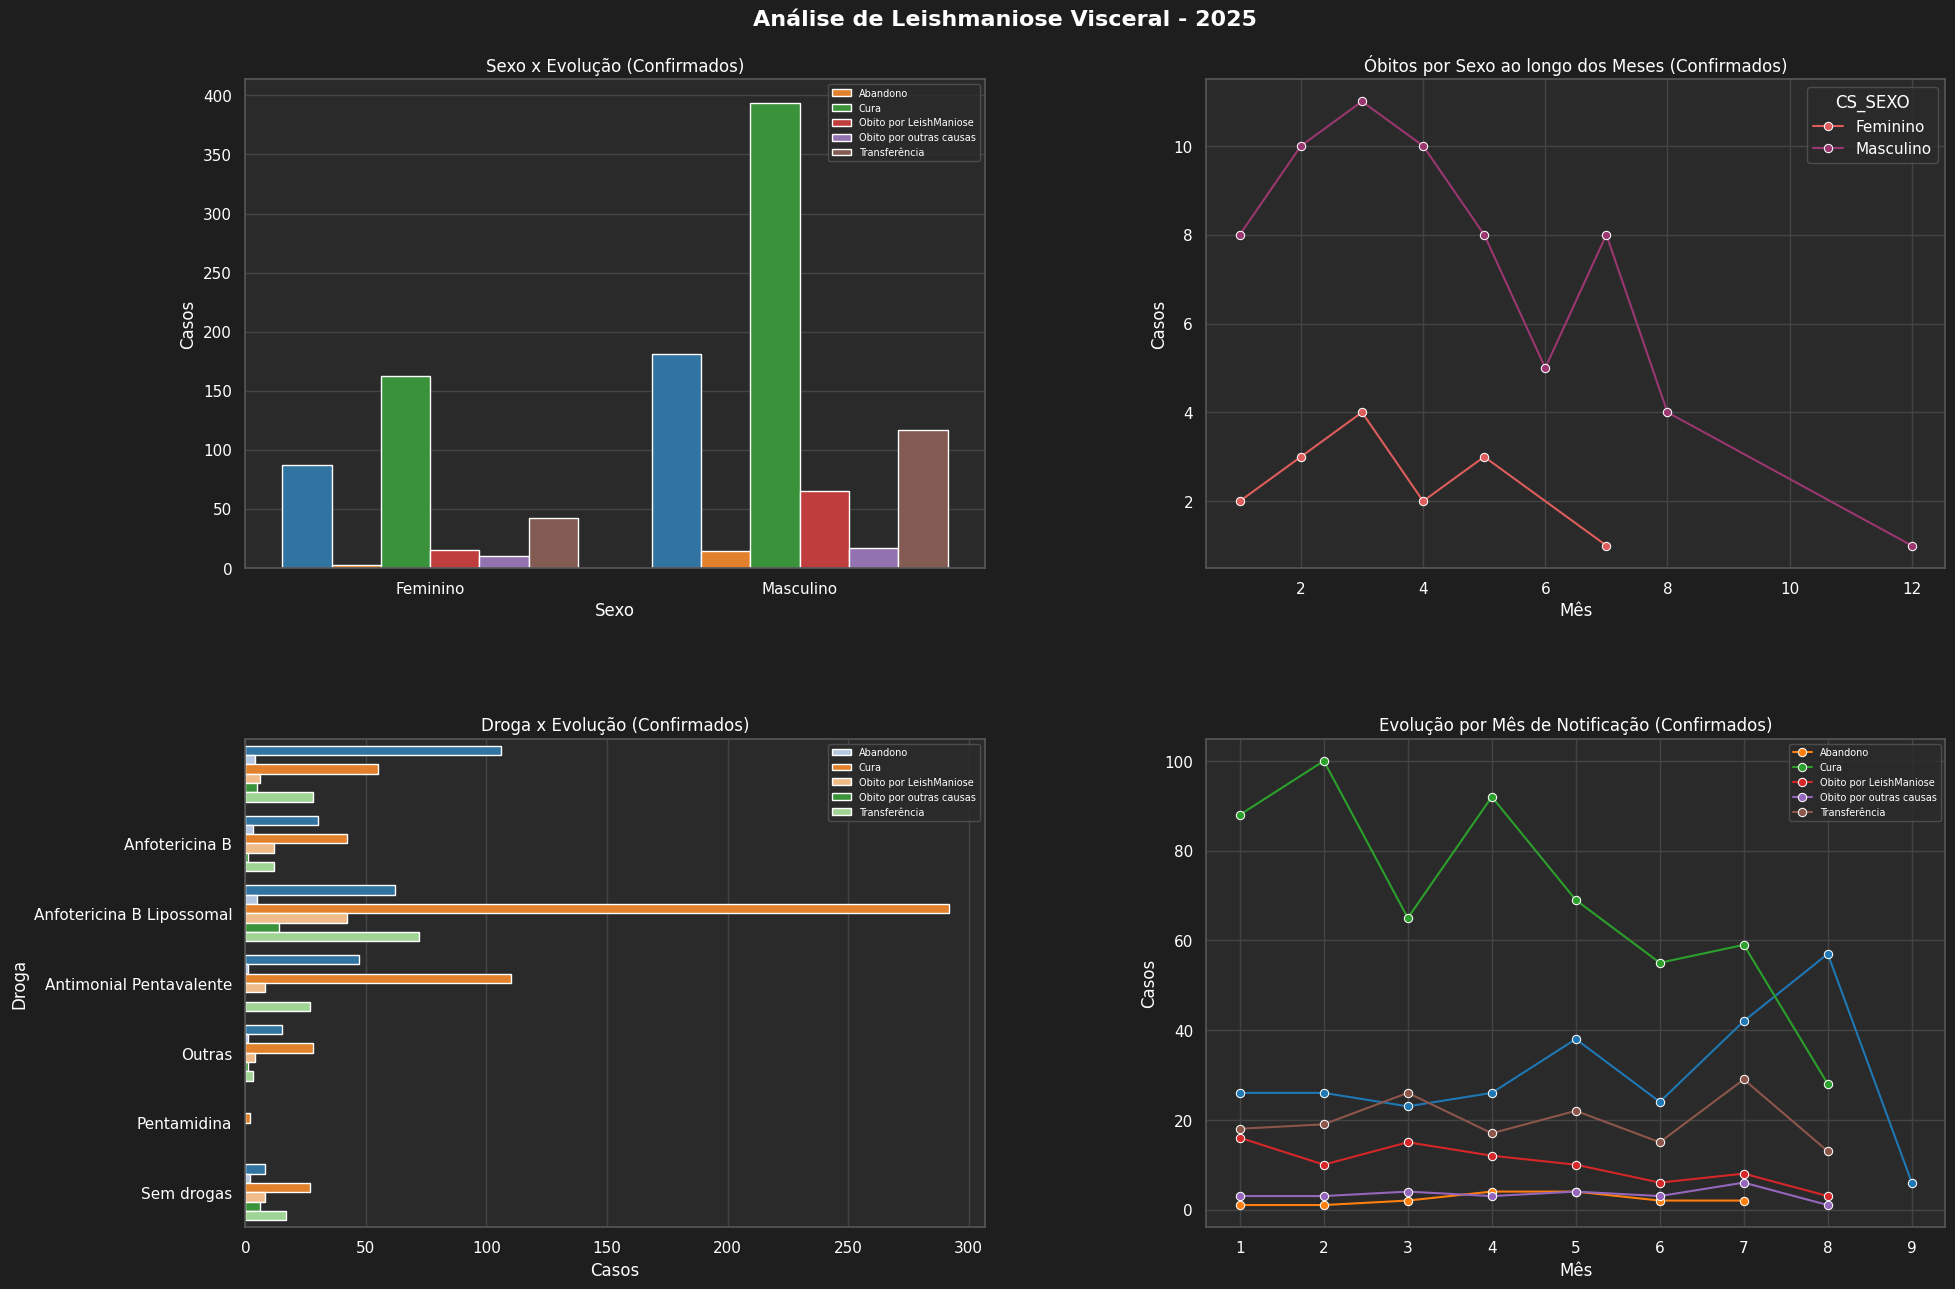

In [171]:
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1e1e1e',
    'axes.facecolor': '#2a2a2a',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#444444',
    'legend.facecolor': '#2a2a2a',
    'legend.edgecolor': '#555555',
})

df_confirmado = df[df['CLASSI_FIN'] == 'Confirmado'].copy()

fig, axes = plt.subplots(2, 2, figsize=(20, 14), facecolor='#1e1e1e')
fig.suptitle('Análise de Leishmaniose Visceral - 2025', fontsize=16,
             fontweight='bold', color='white')

# 1. Sexo x Evolução (confirmados)
sexo_evolucao = df_confirmado.groupby(['CS_SEXO', 'EVOLUCAO']).size().reset_index(name='Casos')
sns.barplot(data=sexo_evolucao, x='CS_SEXO', y='Casos', hue='EVOLUCAO',
            ax=axes[0, 0], palette='tab10')
axes[0, 0].set_title('Sexo x Evolução (Confirmados)')
axes[0, 0].set_xlabel('Sexo')
axes[0, 0].legend(fontsize=7, loc='upper right')

# 2. Óbitos por Sexo ao longo dos Meses
obitos_sexo = df_confirmado[
    df_confirmado['EVOLUCAO'] == 'Obito por LeishManiose'
].groupby(['CS_SEXO', 'MES_OBITO']).size().reset_index(name='Casos')
sns.lineplot(data=obitos_sexo, x='MES_OBITO', y='Casos', hue='CS_SEXO',
             ax=axes[0, 1], palette='flare', marker='o')
axes[0, 1].set_title('Óbitos por Sexo ao longo dos Meses (Confirmados)')
axes[0, 1].set_xlabel('Mês')

# 3. Droga x Evolução
droga_evolucao = df_confirmado.groupby(['DROGA', 'EVOLUCAO']).size().reset_index(name='Casos')
sns.barplot(data=droga_evolucao, x='Casos', y='DROGA', hue='EVOLUCAO',
            ax=axes[1, 0], palette='tab20')
axes[1, 0].set_title('Droga x Evolução (Confirmados)')
axes[1, 0].set_ylabel('Droga')
axes[1, 0].legend(fontsize=7, loc='upper right')

# 4. Evolução por Mês
evolucao_mes = df_confirmado.groupby(['MES_NOTIFIC', 'EVOLUCAO']).size().reset_index(name='Casos')
sns.lineplot(data=evolucao_mes, x='MES_NOTIFIC', y='Casos', hue='EVOLUCAO',
             ax=axes[1, 1], palette='tab10', marker='o')
axes[1, 1].set_title('Evolução por Mês de Notificação (Confirmados)')
axes[1, 1].set_xlabel('Mês')
axes[1, 1].legend(fontsize=7, loc='upper right')

plt.subplots_adjust(top=0.93, hspace=0.35, wspace=0.3, left=0.12, right=0.97)
plt.savefig('analise_leishmaniose_completa.png', dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

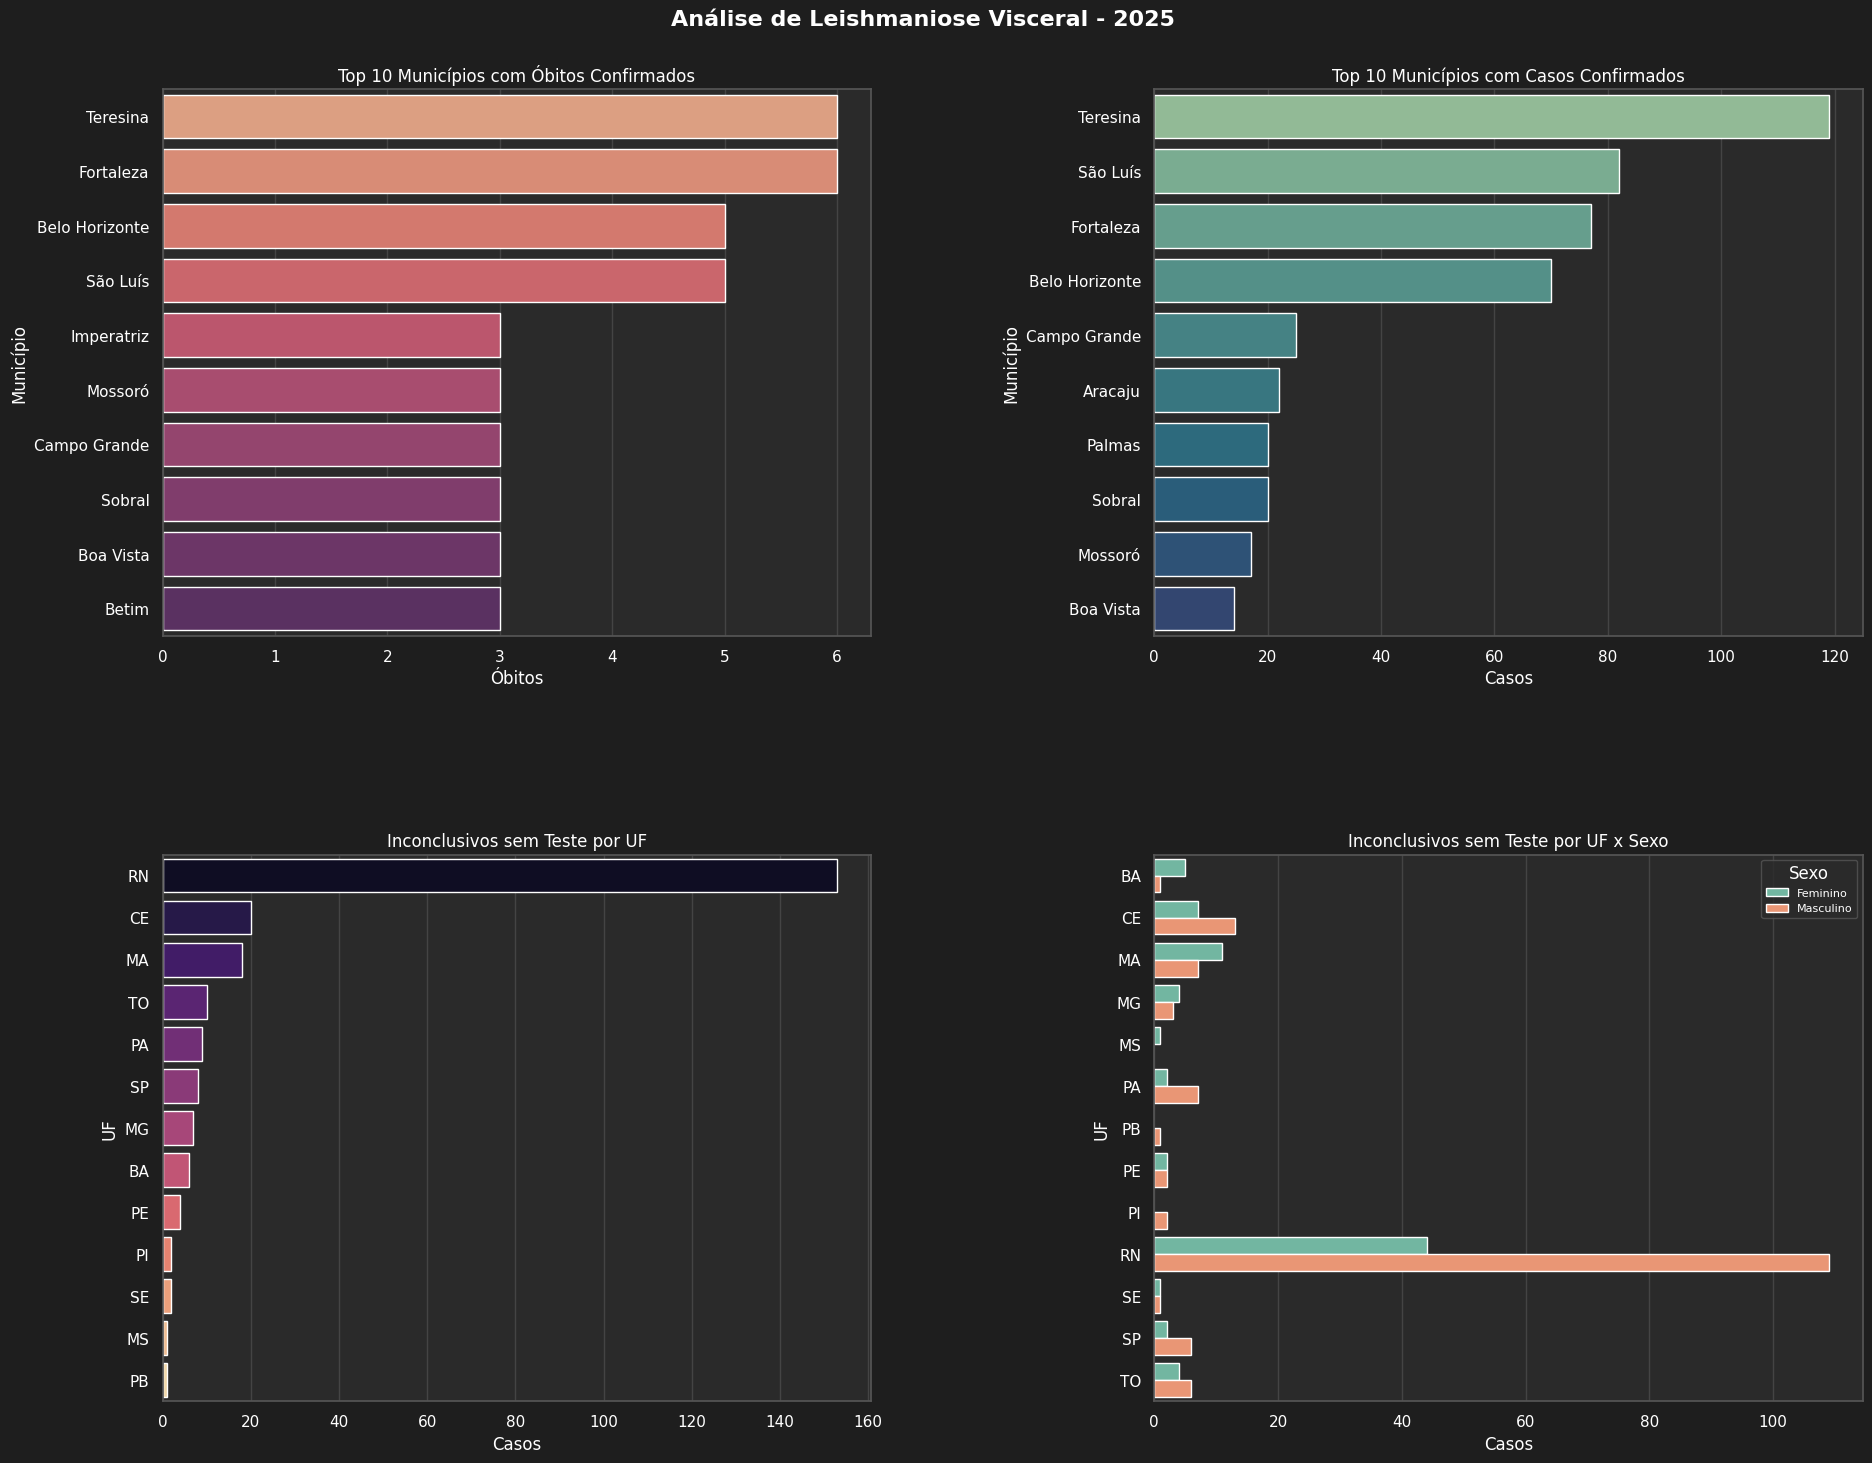

In [172]:
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1e1e1e',
    'axes.facecolor': '#2a2a2a',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#444444',
    'legend.facecolor': '#2a2a2a',
    'legend.edgecolor': '#555555',
})

df_confirmado = df[df['CLASSI_FIN'] == 'Confirmado'].copy()
df_inconclusivo_sem_teste = df[
    (df['CLASSI_FIN'] == 'Inconclusivo') & 
    (df['DIAG_PAR_N'] == 'Não realizado')
].copy()

fig, axes = plt.subplots(2, 2, figsize=(20, 16), facecolor='#1e1e1e')
fig.suptitle('Análise de Leishmaniose Visceral - 2025', fontsize=16,
             fontweight='bold', color='white')

# 1. Top 10 Municípios com óbitos confirmados
mun_obitos = df_confirmado[
    df_confirmado['EVOLUCAO'] == 'Obito por LeishManiose'
]['NOME_MUNICIPIO'].value_counts().head(10).reset_index()
mun_obitos.columns = ['Município', 'Óbitos']
sns.barplot(data=mun_obitos, x='Óbitos', y='Município', hue='Município',
            ax=axes[0, 0], palette='flare', legend=False)
axes[0, 0].set_title('Top 10 Municípios com Óbitos Confirmados')
axes[0, 0].set_xlabel('Óbitos')

# 2. Top 10 Municípios com casos confirmados
mun_confirmados = df_confirmado['NOME_MUNICIPIO'].value_counts().head(10).reset_index()
mun_confirmados.columns = ['Município', 'Casos']
sns.barplot(data=mun_confirmados, x='Casos', y='Município', hue='Município',
            ax=axes[0, 1], palette='crest', legend=False)
axes[0, 1].set_title('Top 10 Municípios com Casos Confirmados')
axes[0, 1].set_xlabel('Casos')

# 3. Inconclusivos sem teste por UF
inc_uf = df_inconclusivo_sem_teste['SG_UF_SIGLA'].value_counts().reset_index()
inc_uf.columns = ['UF', 'Casos']
sns.barplot(data=inc_uf, x='Casos', y='UF', hue='UF',
            ax=axes[1, 0], palette='magma', legend=False)
axes[1, 0].set_title('Inconclusivos sem Teste por UF')
axes[1, 0].set_xlabel('Casos')

# 4. Inconclusivos sem teste por UF x Sexo
inc_sexo_uf = df_inconclusivo_sem_teste.groupby(['SG_UF_SIGLA', 'CS_SEXO']).size().reset_index(name='Casos')
sns.barplot(data=inc_sexo_uf, x='Casos', y='SG_UF_SIGLA', hue='CS_SEXO',
            ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Inconclusivos sem Teste por UF x Sexo')
axes[1, 1].set_ylabel('UF')
axes[1, 1].set_xlabel('Casos')
axes[1, 1].legend(title='Sexo', fontsize=8)

plt.subplots_adjust(top=0.93, hspace=0.4, wspace=0.4, left=0.12, right=0.97)
plt.savefig('analise_leishmaniose_completa2.png', dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

               Grupo  Confirmados  Inconclusivos  Óbitos  Curas
0              Natal           11            142       1     23
1         Parnamirim            1              2       0      0
2  Outros Municípios         1094            234      79   3363
